In [1]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import customfunctions as ctf
from scipy import signal
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from brainflow.data_filter import DataFilter, WindowOperations

In [65]:
# Working path
folder = 'Rawdata' # Esto lo pueden cambiar, pero les recomiendo simplemente usar el mismo nombre
cwd = os.getcwd()
folderpath = os.path.join(cwd,folder)
print(folderpath)


c:\Users\josee\OneDrive\Documentos\GitHub\NeuroHAD2025\FILAnalysis\Rawdata


In [ ]:
# Sessions of interest
sessions = [2, 12, 14, 21, 27, 28, 31, 39, 41, 42]
# Stages
stages = ["baseline", "shared", "individual"]
# Se guardan los datos de las sesiones en un diccionario
preprodata = {
    "p1": {"baseline": [], "shared": [], "individual": []},
    "p2": {"baseline": [], "shared": [], "individual": []},
}

for stage in stages:
    p1holder = []
    p2holder = []
    for sn in sessions:
        p1 = []
        p2 = []
        pattern = f"S{sn}R*"
        snpath = glob.glob(os.path.join(folderpath, pattern))[0]

        p1 = (
            pd.read_csv(os.path.join(snpath, "processed", f"p1_{stage}.csv"))
            .drop(["Unnamed: 0","board_ts","unix_ts"], axis=1)
            .apply(pd.to_numeric, axis=0)
        )
        if stage == 'baseline':
            p1 = p1.iloc[2561:25601,:]
        else:
            p1 = p1.iloc[2561:64001,:]
        p1.subtract(p1.mean(axis=1), axis=0)
        p1.insert(loc=0, column="Session", value=np.ones([p1.shape[0], 1]) * sn)
        p1holder.append(p1)
        p2 = (
            pd.read_csv(os.path.join(snpath, "processed", f"p2_{stage}.csv"))
            .drop("Unnamed: 0", axis=1)
            .replace(["Unnamed: 0","board_ts","unix_ts"], np.nan)
            .dropna()
            .apply(pd.to_numeric, axis=0)
        )
        if stage == 'baseline':
            p2 = p2.iloc[2561:25601,:]
        else:
            p2 = p2.iloc[2561:64001,:]
        p2.subtract(p2.mean(axis=1), axis=0)
        p2.insert(loc=0, column="Session", value=np.ones([p2.shape[0], 1]) * sn)
        p2holder.append(p2)
    p1holder_df = pd.concat(p1holder, ignore_index=True)
    p2holder_df = pd.concat(p2holder, ignore_index=True)
    preprodata["p1"].update({stage:p1holder_df})
    preprodata["p2"].update({stage:p2holder_df})

In [67]:
preprodata['p1']['baseline'][ preprodata['p1']['baseline']['Session'] == 41 ]

,Session,TP9,AF7,AF8,TP10
184320,41.0,-14.041364,-6.539404,-1.280479,-11.557934
184321,41.0,-9.162498,-3.945387,2.076030,-0.540398
184322,41.0,-4.265144,-2.724465,6.571317,10.832084
184323,41.0,-5.084078,-4.637422,7.791570,14.415564
184324,41.0,-7.384743,-8.481916,3.332936,9.785815
...,...,...,...,...,...
207355,41.0,-9.915087,-1.301169,5.301435,-6.122343
207356,41.0,-10.776190,-1.469230,6.588746,-5.346416
207357,41.0,-11.983366,-1.825437,6.540620,-3.909787
207358,41.0,-12.039872,-1.422361,6.506694,1.170623


In [68]:
fs = 256
winsz = 1 
stages = ["baseline", "shared", "individual"]
channels = ["TP9", "TP10", "AF7", "AF8"]
BANDS = [
    ("theta", 4.0, 8.0),
    ("alpha", 8.0, 13.0),
    ("beta", 13.0, 30.0),
    ("gamma", 30.0, 50.0),
]
feats = ['Theta','Alpha','Beta','Gamma', 'TEI']
featcols = [f"{ch}_{ft}" for ch in channels for ft in feats] + ['AlphaAsymmetry']
# Se guardan los datos de las sesiones en un diccionario
metricdata = {
    "p1": {"baseline": [], "shared": [], "individual": []},
    "p2": {"baseline": [], "shared": [], "individual": []},
}

In [69]:
def bandpowers_per_window(winddata, fs, bands=BANDS):
    n_win, win_len = winddata.shape
    n_bands = len(bands)
    out = np.empty((n_win, n_bands), dtype=float)

    nfft = DataFilter.get_nearest_power_of_two(win_len)

    for w in range(n_win):
        sig = winddata[w, :].astype(np.float64)
        psd = DataFilter.get_psd_welch(
            sig,
            nfft,
            nfft // 2,           # overlap 50%
            fs,
            WindowOperations.HANNING.value
        )
        for bi, (_, fmin, fmax) in enumerate(bands):
            out[w, bi] = DataFilter.get_band_power(psd, fmin, fmax)

    return out

def extract_session_bandpowers(sessiondata, channels, fs, winsz, eps=1e-12):
    # --- 1) Calcular bandpowers para cada canal ---
    bandmats = []
    for ch in channels:
        sig = sessiondata[ch].to_numpy()
        wind = ctf.timewindow(sig, fs, winsz, 0)     
        bp = bandpowers_per_window(wind, fs)          
        bandmats.append(bp)


    # --- 2) TEI por canal ---
    tei_list = []
    for bp in bandmats:
        theta = bp[:, 0]
        alpha = bp[:, 1]
        beta  = bp[:, 2]
        tei = beta / (theta + alpha + eps)            
        tei_list.append(tei[:, None])                 

    # --- 3) Alpha Asym (AF8 - AF7) ---
    alpha_AF7 = bandmats[2][:, 1]   # AF7
    alpha_AF8 = bandmats[3][:, 1]   # AF8
    alpha_asym = (np.log(alpha_AF8 + eps) - np.log(alpha_AF7 + eps))[:, None]

    # --- 4) Construir salida EXACTAMENTE en el orden que pediste ---

    rows = []

    for i, ch in enumerate(channels):
        # 4 bandas + TEI
        bp_ch = bandmats[i]                   
        tei_ch = tei_list[i]                
        block = np.concatenate([bp_ch, tei_ch], axis=1) 
        rows.append(block)

    # Unir todos los canales en columnas: (n_win, 5*4 = 20)
    per_channel = np.concatenate(rows, axis=1)

    # Agregar alpha asym al final → (n_win, 21)
    out = np.concatenate([per_channel, alpha_asym], axis=1)

    return out

for stage in stages:
    stagedata1 = preprodata['p1'][stage].copy()
    stagedata2 = preprodata['p2'][stage].copy()
    stageholder1 = []
    stageholder2 = []
    for sn in sessions:
        sessiondata1 = stagedata1[stagedata1["Session"]==sn].drop("Session",axis=1)
        bandmat1 = extract_session_bandpowers(sessiondata1, channels, fs, winsz)
        bandmat1_df = pd.DataFrame(bandmat1,columns=featcols,dtype=float)
        bandmat1_df.insert(loc=0, column="Session", value=np.ones([bandmat1_df.shape[0], 1]) * sn)
        stageholder1.append(bandmat1_df)


        sessiondata2 = stagedata2[stagedata2["Session"]==sn].drop("Session",axis=1)
        bandmat2 = extract_session_bandpowers(sessiondata2, channels, fs, winsz)
        bandmat2_df = pd.DataFrame(bandmat2,columns=featcols,dtype=float)
        bandmat2_df.insert(loc=0, column="Session", value=np.ones([bandmat2_df.shape[0], 1]) * sn)
        stageholder2.append(bandmat2_df)
    
    stageholder1_df = pd.concat(stageholder1, ignore_index=True)
    metricdata["p1"].update({stage:stageholder1_df})

    stageholder2_df = pd.concat(stageholder2, ignore_index=True)
    metricdata["p2"].update({stage:stageholder2_df})



In [70]:
key = 'individual'
metricdata['p2'][key]

,Session,TP9_Theta,TP9_Alpha,TP9_Beta,TP9_Gamma,TP9_TEI,TP10_Theta,TP10_Alpha,TP10_Beta,TP10_Gamma,...,AF7_Alpha,AF7_Beta,AF7_Gamma,AF7_TEI,AF8_Theta,AF8_Alpha,AF8_Beta,AF8_Gamma,AF8_TEI,AlphaAsymmetry
0,2.0,14.109942,6.006231,25.874253,7.920394,1.286241,20.370340,16.461000,23.402415,4.050890,...,1442.761720,6732.056343,1197.678406,1.893556,1706.951134,653.129182,6343.023127,1028.470205,2.687630,-0.792539
1,2.0,3.685103,4.502629,12.171170,8.854938,1.486513,11.167157,7.525564,11.782076,3.768321,...,280.376830,8647.765697,1634.799458,17.484700,403.272377,159.787798,6349.030284,1407.011830,11.275936,-0.562288
2,2.0,8.908732,8.219101,13.976502,5.377680,0.816011,3.936331,4.930850,11.283258,4.645000,...,171.468255,9828.040346,1262.390864,32.853748,56.883012,77.664213,7921.331006,1115.392402,58.873983,-0.792004
3,2.0,7.224718,6.016529,10.996099,6.018672,0.830443,4.082532,6.971262,9.365077,1.550672,...,538.072537,6110.331852,1156.161120,1.746221,1330.251207,391.031322,5771.928751,1261.427644,3.353272,-0.319206
4,2.0,14.454519,5.522313,26.097963,3.892740,1.306411,19.353652,14.337612,13.289673,3.712102,...,228.486227,10606.134096,1567.232145,31.319185,148.678522,233.492364,8735.713239,1450.878049,22.858134,0.021673
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,42.0,11.684284,6.973121,48.202031,17.586844,2.583534,6.074269,4.607561,11.423522,7.616726,...,434.647885,11800.664393,2339.158536,21.466708,1.838179,1.924906,4.610039,2.836695,1.225069,-5.419659
2396,42.0,26.360426,7.778185,24.931230,16.832299,0.730294,50.052759,15.730680,27.374902,11.203814,...,1419.096101,10541.207038,1320.553717,5.027505,20.636995,2.858599,4.529422,1.786241,0.192778,-6.207444
2397,42.0,15.367237,9.679461,25.544800,11.120667,1.019887,24.505115,9.240507,67.620277,10.393152,...,267.560334,8013.726080,1620.151011,16.096096,7.051464,3.272318,5.178971,2.518025,0.501654,-4.403846
2398,42.0,12.409074,9.438015,27.300481,10.041444,1.249616,15.867166,15.173736,37.291952,12.792865,...,662.967982,6927.532528,1628.722871,6.287099,4.779865,4.040594,10.645911,1.730409,1.206956,-5.100335


In [71]:
metricdata['p1'][key]

,Session,TP9_Theta,TP9_Alpha,TP9_Beta,TP9_Gamma,TP9_TEI,TP10_Theta,TP10_Alpha,TP10_Beta,TP10_Gamma,...,AF7_Alpha,AF7_Beta,AF7_Gamma,AF7_TEI,AF8_Theta,AF8_Alpha,AF8_Beta,AF8_Gamma,AF8_TEI,AlphaAsymmetry
0,2.0,27.496416,16.574023,26.416486,10.846976,0.599415,18.890966,5.942348,11.860738,9.645034,...,2.718456,5.492981,4.510965,1.074362,85.361449,82.750835,5516.426611,1411.240054,32.813941,3.415770
1,2.0,330.478645,105.810016,41.155877,28.510542,0.094332,361.758369,89.739726,39.426255,25.604836,...,67.267188,74.508063,35.786982,0.385490,196.924941,945.919015,6591.155567,1488.386111,5.767328,2.643484
2,2.0,1.766462,6.823042,33.591551,12.946941,3.910767,3.325901,6.900535,18.732681,7.043087,...,139.048544,72.344655,12.547647,0.183261,55.715798,199.527236,6876.033868,1085.019495,26.939164,0.361128
3,2.0,2.244680,3.961852,30.072920,13.027539,4.845366,1.937238,0.557966,18.431360,9.260996,...,3.454601,9.907690,5.178701,1.981606,78.734696,219.226040,7435.413078,1137.559806,24.954339,4.150397
4,2.0,1.247667,3.298389,19.831375,6.593517,4.362325,2.360641,3.283723,10.884173,3.260849,...,4.198363,7.521099,4.166869,0.783887,74.093704,364.612933,6042.226757,1720.077040,13.772818,4.464142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,42.0,6.265141,1.774643,26.623804,8.017997,3.311507,2.680029,3.308803,33.169469,14.793818,...,0.656993,6.450577,3.424058,2.154913,2.417457,2.729597,5.916225,1.941108,1.149439,1.424236
2396,42.0,9.086389,7.834597,26.952639,5.353691,1.592853,2.044585,1.773732,26.323537,9.034120,...,1.209866,7.160520,2.162620,1.841509,4.515421,1.859945,4.644111,1.543895,0.728446,0.430037
2397,42.0,4.698727,2.730790,19.150346,6.834740,2.577603,8.789433,5.012271,37.744949,11.489517,...,3.394685,10.740676,7.391197,1.314495,5.059117,1.474661,4.175437,1.692558,0.639054,-0.833783
2398,42.0,12.367158,4.378917,17.458141,6.901613,1.042521,6.626825,1.395995,16.553507,8.858258,...,4.355251,7.219729,3.200955,1.179866,2.658389,2.503785,2.708466,1.858297,0.524675,-0.553578


In [72]:
channels = ["TP9", "TP10", "AF7", "AF8"]
BANDS = [
    ("theta", 4.0, 8.0),
    ("alpha", 8.0, 13.0),
    ("beta", 13.0, 30.0),
    ("gamma", 30.0, 50.0),
]
def cross_bicoherence_matrix(winddata1, winddata2, fs, eps=1e-12, fmax=50):
    """
    winddata1, winddata2: arrays (n_ventanas, n_muestras) de p1 y p2
    fs: frecuencia de muestreo
    fmax: frecuencia máxima a considerar

    Devuelve:
        freqs: vector de frecuencias
        b2_df: DataFrame (F x F) con bicoherencia b^2(f1,f2) en [0,1]
               index y columns = freqs
    """

    n_win, n_samp = winddata1.shape
    assert winddata2.shape == winddata1.shape

    # Ventanado
    win = signal.get_window('hann', n_samp)

    # FFT por ventana
    X1 = np.fft.rfft(winddata1 * win, axis=1)  # (K, F_total)
    X2 = np.fft.rfft(winddata2 * win, axis=1)

    freqs = np.fft.rfftfreq(n_samp, 1.0/fs)

    # Recorte a fmax
    F_lim = np.searchsorted(freqs, fmax, side="right")
    freqs = freqs[:F_lim]
    X1 = X1[:, :F_lim]
    X2 = X2[:, :F_lim]
    F = F_lim

    num    = np.zeros((F, F), dtype=np.complex128)
    denom1 = np.zeros((F, F), dtype=np.float64)
    denom2 = np.zeros((F, F), dtype=np.float64)

    for k in range(n_win):
        X1k = X1[k]
        X2k = X2[k]
        for f1 in range(F):
            for f2 in range(F - f1):  # f1+f2 < F
                f3 = f1 + f2
                prod = X1k[f1] * X1k[f2] * np.conjugate(X2k[f3])
                num[f1, f2]   += prod
                denom1[f1, f2] += np.abs(X1k[f1] * X1k[f2])**2
                denom2[f1, f2] += np.abs(X2k[f3])**2

    num /= n_win
    B  = num
    b2 = (np.abs(B)**2) / (denom1 * denom2 + eps)

    # DataFrame con freqs en rows y cols
    b2_df = pd.DataFrame(b2, index=freqs, columns=freqs)

    return freqs, b2_df

In [73]:
fs_bi = 256
winsz_bi = 2     

bico_data = {
    "baseline": [],
    "shared": [],
    "individual": [],
}

# Estructura: bico_data[stage][sn][(ch1, ch2)] = DataFrame bico (freq x freq)
bico_data = {stage: {} for stage in stages}

# Todos los pares, incluyendo mismos canales
channel_pairs = [(ch1, ch2) for ch1 in channels for ch2 in channels]

for stage in stages:
    stagedata1 = preprodata['p1'][stage].copy()
    stagedata2 = preprodata['p2'][stage].copy()

    for sn in sessions:
        sessiondata1 = stagedata1[stagedata1["Session"] == sn].drop("Session", axis=1)
        sessiondata2 = stagedata2[stagedata2["Session"] == sn].drop("Session", axis=1)

        if sn not in bico_data[stage]:
            bico_data[stage][sn] = {}

        for ch1, ch2 in channel_pairs:
            sig1 = sessiondata1[ch1].to_numpy()
            sig2 = sessiondata2[ch2].to_numpy()

            wind1 = ctf.timewindow(sig1, fs_bi, winsz_bi, 0)  # (n_ventanas, n_muestras)
            wind2 = ctf.timewindow(sig2, fs_bi, winsz_bi, 0)

            freqs, b2_df = cross_bicoherence_matrix(wind1, wind2, fs_bi)

            # Guardamos directamente el DataFrame
            bico_data[stage][sn][(ch1, ch2)] = b2_df

In [74]:
bico_data["shared"][39][("TP9", "TP9")]


,0.0,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,...,45.5,46.0,46.5,47.0,47.5,48.0,48.5,49.0,49.5,50.0
0.0,3.421248e-08,3.843877e-08,4.465661e-07,8.271581e-07,7.436718e-07,3.897890e-07,1.902954e-07,1.901775e-07,1.543233e-08,2.933267e-07,...,6.650865e-07,1.938169e-06,5.212802e-07,2.542225e-07,8.154663e-07,5.903271e-07,1.413543e-06,7.990510e-07,1.191937e-07,2.027709e-07
0.5,3.843877e-08,1.414725e-09,5.308516e-07,5.659827e-08,3.324409e-08,1.737944e-07,2.791493e-07,3.284036e-07,2.858481e-07,4.953359e-07,...,5.650885e-08,6.718458e-08,5.983022e-08,5.901527e-07,1.586034e-06,5.876646e-07,2.588525e-07,3.551703e-07,1.458126e-07,0.000000e+00
1.0,4.465661e-07,5.308516e-07,1.246069e-06,1.577667e-07,3.918863e-07,2.065288e-07,1.732125e-07,6.235081e-08,3.554822e-07,3.553192e-07,...,1.499326e-06,1.231684e-06,6.441430e-07,1.805437e-07,1.046826e-07,1.898512e-08,1.560118e-07,3.290561e-08,0.000000e+00,0.000000e+00
1.5,8.271581e-07,5.659827e-08,1.577667e-07,1.301513e-06,3.994772e-07,1.382451e-07,5.964668e-07,2.327181e-07,2.255353e-07,6.499336e-07,...,8.259079e-08,4.491848e-08,6.105895e-07,6.896214e-08,4.691577e-07,3.868351e-07,9.590048e-08,0.000000e+00,0.000000e+00,0.000000e+00
2.0,7.436718e-07,3.324409e-08,3.918863e-07,3.994772e-07,9.136504e-07,5.120596e-07,5.962662e-07,3.723929e-07,1.048097e-07,4.473846e-08,...,3.941116e-08,7.090029e-07,1.498923e-06,7.972582e-07,3.344340e-07,3.606015e-07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48.0,5.903271e-07,5.876646e-07,1.898512e-08,3.868351e-07,3.606015e-07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
48.5,1.413543e-06,2.588525e-07,1.560118e-07,9.590048e-08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
49.0,7.990510e-07,3.551703e-07,3.290561e-08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
49.5,1.191937e-07,1.458126e-07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


<Axes: >

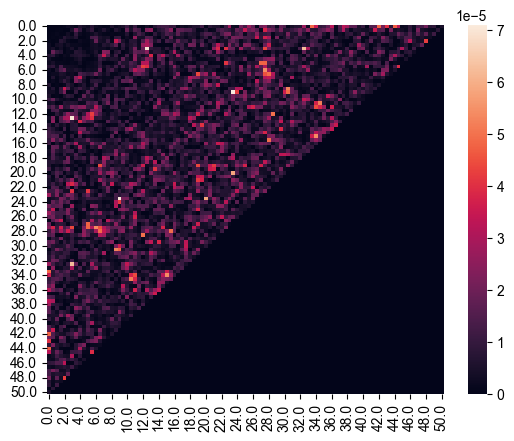

In [28]:
sns.heatmap(bico_data["baseline"][2][("AF8","AF8")])

<Axes: >

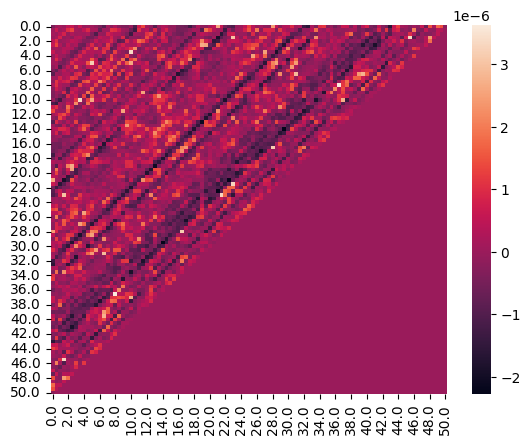

In [76]:
df_base = bico_data["individual"][sn][("TP9","AF7")]
df_ind  = bico_data["shared"][sn][("TP9","AF7")]
df_diff = df_ind - df_base
sns.heatmap(df_diff)


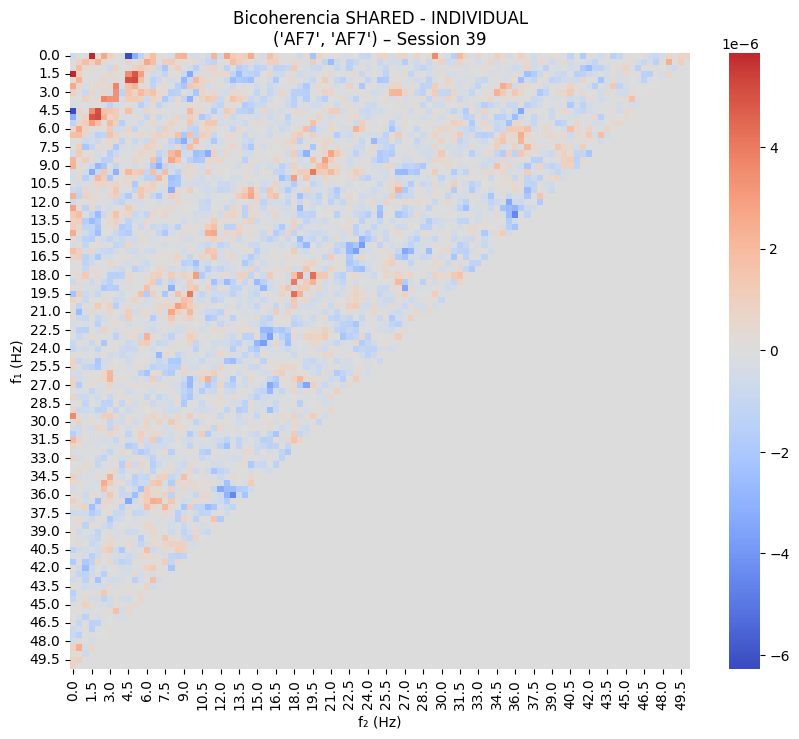

In [77]:
sn = 39  # ejemplo de sesión
ch_pair = ("AF7", "AF7")

df_shared = bico_data["shared"][sn][ch_pair]
df_ind    = bico_data["individual"][sn][ch_pair]

diff = df_shared - df_ind

plt.figure(figsize=(10,8))
sns.heatmap(diff, cmap="coolwarm", center=0)
plt.title(f"Bicoherencia SHARED - INDIVIDUAL\n{ch_pair} – Session {sn}")
plt.xlabel("f₂ (Hz)")
plt.ylabel("f₁ (Hz)")
plt.show()


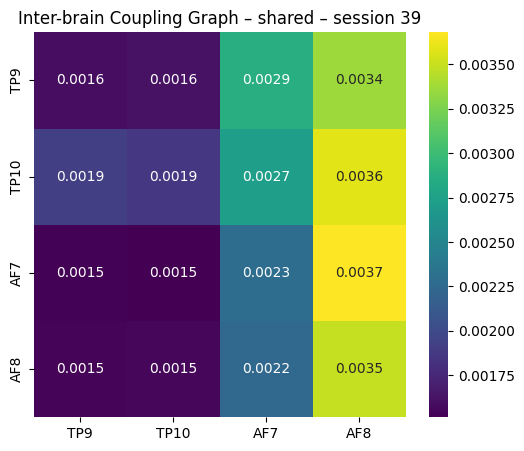

In [78]:
def sync_index(df):
    return df.to_numpy().sum()


sn = 39
stage = "shared"

graph = np.zeros((4,4))

for i,ch1 in enumerate(channels):
    for j,ch2 in enumerate(channels):
        df = bico_data[stage][sn][(ch1,ch2)]
        graph[i,j] = sync_index(df)

plt.figure(figsize=(6,5))
sns.heatmap(graph, annot=True, cmap="viridis",
            xticklabels=channels, yticklabels=channels)
plt.title(f"Inter-brain Coupling Graph – {stage} – session {sn}")
plt.show()


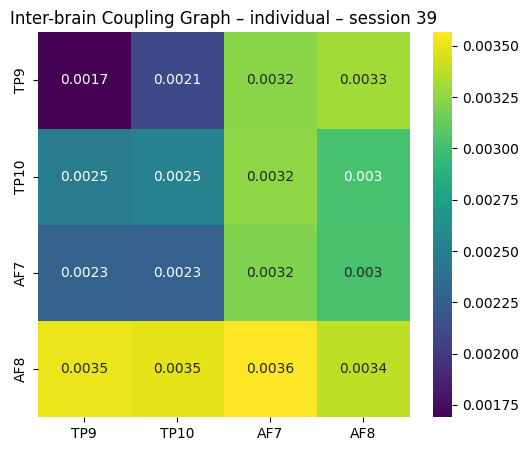

In [79]:
sn = 39
stage = "individual"

graph = np.zeros((4,4))

for i,ch1 in enumerate(channels):
    for j,ch2 in enumerate(channels):
        df = bico_data[stage][sn][(ch1,ch2)]
        graph[i,j] = sync_index(df)

plt.figure(figsize=(6,5))
sns.heatmap(graph, annot=True, cmap="viridis",
            xticklabels=channels, yticklabels=channels)
plt.title(f"Inter-brain Coupling Graph – {stage} – session {sn}")
plt.show()

In [2]:
import pickle

# with open(r"C:\Users\josee\OneDrive\Documentos\GitHub\NeuroHAD2025\FILAnalysis\metricdata.pkl", "wb") as f:
#     pickle.dump(metricdata, f)

# with open(r"C:\Users\josee\OneDrive\Documentos\GitHub\NeuroHAD2025\FILAnalysis\bicodata.pkl", "wb") as f:
#     pickle.dump(bico_data, f)

# Cargar
with open(r"C:\Users\josee\OneDrive\Documentos\GitHub\NeuroHAD2025\FILAnalysis\metricdata.pkl", "rb") as f:
    metricdata = pickle.load(f)

with open(r"C:\Users\josee\OneDrive\Documentos\GitHub\NeuroHAD2025\FILAnalysis\bicodata.pkl", "rb") as f:
    bico_data = pickle.load(f)

In [3]:
metricdata['p1']['baseline']

,Session,TP9_Theta,TP9_Alpha,TP9_Beta,TP9_Gamma,TP9_TEI,TP10_Theta,TP10_Alpha,TP10_Beta,TP10_Gamma,...,AF7_Alpha,AF7_Beta,AF7_Gamma,AF7_TEI,AF8_Theta,AF8_Alpha,AF8_Beta,AF8_Gamma,AF8_TEI,AlphaAsymmetry
0,2.0,394.683798,110.004557,27.308637,8.679185,0.054110,401.802459,128.869470,31.575761,10.837274,...,19.294967,26.874782,7.267522,0.167179,124.661462,53.811223,57.499552,17.048099,0.322176,1.025638
1,2.0,70.011300,77.032690,45.632676,15.760804,0.310334,84.014212,61.345186,35.790482,16.405601,...,38.568779,46.655168,7.237380,0.571897,109.422805,74.049635,56.040219,9.642548,0.305442,0.652292
2,2.0,519.405527,327.699455,66.481534,13.934991,0.078481,534.275229,331.625150,62.618991,9.425905,...,19.387555,20.793888,10.726559,0.321668,128.700954,35.658001,56.018532,29.060374,0.340830,0.609342
3,2.0,13.346784,18.766287,12.412673,6.588119,0.386530,13.820024,19.404453,19.124524,4.318552,...,18.934087,18.869400,5.197725,0.475860,53.108216,32.592646,63.843445,18.982488,0.744957,0.543123
4,2.0,159.726650,167.902320,35.860061,5.261767,0.109453,106.479423,151.280157,28.779045,5.064295,...,40.354053,24.594565,4.191344,0.284854,91.540486,23.779966,50.404056,10.957087,0.437078,-0.528848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,42.0,1.584823,0.646899,2.331344,1.465395,1.044639,0.980651,0.940618,13.423792,2.895665,...,0.617892,3.704373,1.638034,0.833007,0.431877,1.219690,9.084356,1.849335,5.500447,0.680038
896,42.0,7.037001,3.261685,5.897118,1.007915,0.572609,7.787159,5.898466,4.250374,2.129802,...,0.789701,4.330698,0.819494,3.199040,1.098173,2.453380,7.538094,2.602069,2.122478,1.133567
897,42.0,2.021420,2.812369,5.789797,0.915559,1.197776,3.706650,1.389820,7.839630,2.367719,...,1.996484,1.924710,1.388182,0.426802,1.780000,1.534397,4.563212,1.824531,1.376785,-0.263250
898,42.0,2.456073,2.212446,4.761442,3.001026,1.019904,2.948229,4.644303,4.662223,2.080504,...,0.437663,3.230043,1.460712,2.225191,1.256331,1.275693,8.126936,1.039746,3.209660,1.069796


In [4]:
bico_data['baseline'][2][('TP9','TP9')]

,0.0,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,...,45.5,46.0,46.5,47.0,47.5,48.0,48.5,49.0,49.5,50.0
0.0,5.046970e-07,0.000011,3.744789e-06,1.979743e-05,8.571788e-07,0.000017,0.000025,0.000009,4.661330e-06,3.383781e-05,...,6.642139e-06,0.000009,0.000001,0.000010,0.000015,5.118730e-06,1.417063e-05,6.745120e-05,0.000024,0.000023
0.5,1.127133e-05,0.000008,3.542000e-05,2.322693e-05,1.839434e-05,0.000024,0.000002,0.000017,3.673616e-05,3.373762e-05,...,1.387261e-05,0.000004,0.000010,0.000006,0.000004,6.200058e-06,5.066981e-06,8.890681e-06,0.000023,0.000000
1.0,3.744789e-06,0.000035,5.422740e-06,7.868694e-06,6.432196e-06,0.000008,0.000038,0.000010,2.730822e-07,5.269109e-08,...,1.289735e-05,0.000011,0.000012,0.000009,0.000004,4.621264e-06,1.640609e-05,8.424046e-07,0.000000,0.000000
1.5,1.979743e-05,0.000023,7.868694e-06,1.533075e-05,1.504720e-05,0.000034,0.000036,0.000020,4.216636e-06,2.498435e-06,...,1.232648e-06,0.000001,0.000004,0.000018,0.000009,9.054695e-07,9.934328e-07,0.000000e+00,0.000000,0.000000
2.0,8.571788e-07,0.000018,6.432196e-06,1.504720e-05,2.872704e-05,0.000020,0.000008,0.000003,3.220721e-06,4.636222e-06,...,2.223651e-07,0.000002,0.000009,0.000010,0.000002,1.639569e-07,0.000000e+00,0.000000e+00,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48.0,5.118730e-06,0.000006,4.621264e-06,9.054695e-07,1.639569e-07,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
48.5,1.417063e-05,0.000005,1.640609e-05,9.934328e-07,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
49.0,6.745120e-05,0.000009,8.424046e-07,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
49.5,2.411182e-05,0.000023,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000


In [5]:
def remove_iqr_outliers(df, session_col="Session"):
    df_clean = []

    # Filtrar solo columnas numéricas (evita problemas si hay strings)
    numeric_cols = df.select_dtypes(include="number").columns.drop(session_col)

    # Loop por sesión
    for session, group in df.groupby(session_col):

        # Calcular Q1, Q3 e IQR por columna
        Q1 = group[numeric_cols].quantile(0.25)
        Q3 = group[numeric_cols].quantile(0.75)
        IQR = Q3 - Q1

        # Rango permitido
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Crear máscara de outliers: True si el valor está fuera del rango
        outlier_mask = (group[numeric_cols] < lower_bound) | (group[numeric_cols] > upper_bound)

        # Filas que NO tienen ningún outlier en ninguna columna
        rows_to_keep = ~outlier_mask.any(axis=1)

        df_clean.append(group[rows_to_keep])

    return pd.concat(df_clean, ignore_index=True)




In [6]:
def normalize(baseline, data, id_cols=("Session",)):
    cols = baseline.columns
    feature_cols = [c for c in cols if c not in id_cols]

    scaler = StandardScaler()
    sessions = baseline['Session'].unique()
    data_scaled = data.copy()
    for sn in sessions:
        # baseline de esa sesión
        base_sn = baseline[baseline['Session'] == sn]
        
        # datos de esa sesión
        data_sn = data_scaled[data_scaled['Session'] == sn]
        
        if len(base_sn) == 0 or len(data_sn) == 0:
            continue
        
        # fit scaler SOLO con baseline de esa sesión
        scaler = StandardScaler()
        scaler.fit(base_sn[feature_cols])
        
        # transformar datos de esa sesión
        data_scaled.loc[data_scaled[id_cols[0]] == sn, feature_cols] = \
            scaler.transform(data_sn[feature_cols])
    
    return data_scaled

In [7]:
# ---- 1. Función para agregar columnas promediadas por banda ----
def add_band_means(df):
    df = df.copy()
    
    df["Theta"] = df[[c for c in df.columns if "_Theta" in c]].mean(axis=1)
    df["Alpha"] = df[[c for c in df.columns if "_Alpha" in c and "Asym" not in c]].mean(axis=1)
    df["Beta"]  = df[[c for c in df.columns if "_Beta"  in c]].mean(axis=1)
    df["TEI"]   = df[[c for c in df.columns if "_TEI"   in c]].mean(axis=1)

    # Ya existe columna única
    df["AlphaAsymmetry"] = df["AlphaAsymmetry"]

    return df


# ---- 2. Primero crear los promedios en baseline y en los stages ----
p1_base_mean = add_band_means(metricdata['p1']['baseline'])
p1_shared_mean = add_band_means(metricdata['p1']['shared'])
p1_indiv_mean  = add_band_means(metricdata['p1']['individual'])

p2_base_mean = add_band_means(metricdata['p2']['baseline'])
p2_shared_mean = add_band_means(metricdata['p2']['shared'])
p2_indiv_mean  = add_band_means(metricdata['p2']['individual'])


# ---- 3. Luego normalizar usando baseline de cada sujeto ----
p1_shared_z = normalize(p1_base_mean, p1_shared_mean)
p1_indiv_z  = normalize(p1_base_mean, p1_indiv_mean)

p2_shared_z = normalize(p2_base_mean, p2_shared_mean)
p2_indiv_z  = normalize(p2_base_mean, p2_indiv_mean)


In [8]:
p1_shared_z

,Session,TP9_Theta,TP9_Alpha,TP9_Beta,TP9_Gamma,TP9_TEI,TP10_Theta,TP10_Alpha,TP10_Beta,TP10_Gamma,...,AF8_Theta,AF8_Alpha,AF8_Beta,AF8_Gamma,AF8_TEI,AlphaAsymmetry,Theta,Alpha,Beta,TEI
0,2.0,-0.627944,-0.600889,-0.532307,-0.522657,1.073077,-0.633617,-0.616843,-0.801976,-0.040157,...,-0.571659,3.281351,299.837578,111.010296,54.061551,2.906035,-0.677687,-0.153789,144.903233,17.328367
1,2.0,-0.587054,-0.560391,-0.658318,0.814209,-0.175963,-0.607126,-0.522465,-0.717806,0.061134,...,1.045186,6.834578,300.685069,104.101718,23.733609,2.095064,-0.485047,0.411625,145.338470,6.748477
2,2.0,-0.613527,-0.563483,-0.271590,1.733704,0.541553,-0.621458,-0.578507,-0.127941,0.489346,...,36.835462,33.528796,389.088570,142.129922,2.376967,3.630840,2.963673,4.010449,188.640495,0.984728
3,2.0,-0.563939,-0.484231,-0.105864,4.015755,-0.096839,-0.566001,-0.551590,-0.042702,1.470420,...,5.608412,38.872640,340.231262,166.899754,5.216442,3.913634,-0.015169,4.783168,165.128944,1.772293
4,2.0,-0.625137,-0.617151,0.034081,1.469500,2.630559,-0.628793,-0.606160,-0.337657,-0.977449,...,0.700761,9.001282,364.296734,123.967353,25.647344,3.323491,-0.551678,0.624128,176.527526,9.349534
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,42.0,2.959610,1.024064,7.069828,13.110715,-0.900628,2.463259,0.982424,5.604838,13.714165,...,8.600422,2.399401,0.396648,1.459162,-1.082319,0.120586,2.809558,1.132849,6.867042,-1.238691
2396,42.0,-0.326328,-0.210735,0.339401,11.514130,-0.041326,-0.190973,0.125119,6.197716,14.960445,...,10.008896,4.004464,0.835007,-0.814655,-1.086540,2.738449,-0.130602,0.071231,3.336338,-0.557190
2397,42.0,-0.323310,-0.046526,6.053181,10.597355,2.005896,-0.222576,-0.136453,4.602515,10.873664,...,1.377788,-0.510886,-0.371999,-0.699834,-0.807371,-0.120503,-0.259133,-0.125107,5.250891,0.355223
2398,42.0,-0.003993,0.872073,2.664818,11.479386,-0.658329,0.046801,0.869321,1.450260,7.418462,...,2.031517,2.333290,-0.953425,0.185454,-1.054011,0.686479,0.071653,0.961446,1.662329,-1.284015


In [9]:
import mne

def get_topo_values(df, band="Alpha", session_col="Session"):
    """
    Devuelve un vector con el valor promedio por canal para una banda dada,
    promediando sobre todas las sesiones y ventanas.
    Asume columnas tipo 'TP9_Alpha', 'AF7_Alpha', etc.
    """

    # columnas de esa banda
    band_cols = [c for c in df.columns if c.endswith(f"_{band}")]
    
    # promedio por sesión (sobre filas/ventanas)
    session_means = df.groupby(session_col)[band_cols].mean()
    
    # promedio final sobre sesiones
    topo_vals = session_means.mean(axis=0)

    # índice → nombre de canal (quita el sufijo _Banda)
    topo_vals.index = [c.split("_")[0] for c in topo_vals.index]

    return topo_vals  # Series: index = canales, values = potencia media (ya normalizada)

def plot_topomap_from_series(topo_vals, title="", vmin=None, vmax=None):
    """
    topo_vals: pd.Series con index = nombres de canal (TP9, AF7, etc.)
               y values = valor escalar (por ejemplo z-score medio de banda).
    """

    ch_names = list(topo_vals.index)
    data = topo_vals.values

    info = mne.create_info(ch_names=ch_names, sfreq=256, ch_types="eeg")
    montage = mne.channels.make_standard_montage("standard_1020")
    info.set_montage(montage)

    mne.viz.plot_topomap(
        data,
        info,
        cmap="RdBu_r",
        contours=0,
        # cmap_params=dict(vmin=vmin, vmax=vmax)
    )

    import matplotlib.pyplot as plt
    plt.title(title)
    plt.show()




In [10]:
def plot_topomap_grid(p1_shared_topo, p1_indiv_topo,
                      p2_shared_topo, p2_indiv_topo,
                      band="Alpha", figsize=(8, 6)):
    """
    Crea una figura 2x2 con topoplots:
    
        p1 Shared      | p1 Individual
        p2 Shared      | p2 Individual
    
    Todas las escalas de color se comparten.
    """

    # asumimos mismos canales en todas las series
    ch_names = list(p1_shared_topo.index)

    # info + montaje
    info = mne.create_info(ch_names=ch_names, sfreq=256, ch_types="eeg")
    montage = mne.channels.make_standard_montage("standard_1020")
    info.set_montage(montage)

    # datos y títulos
    data_series = [
        p1_shared_topo,
        p1_indiv_topo,
        p2_shared_topo,
        p2_indiv_topo,
    ]
    titles = [
        f"p1 - {band} - Shared",
        f"p1 - {band} - Individual",
        f"p2 - {band} - Shared",
        f"p2 - {band} - Individual",
    ]

    # escala común
    all_vals = np.concatenate([s.values for s in data_series])
    vmin, vmax = all_vals.min(), all_vals.max()

    # figura 2x2
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.ravel()

    for ax, series, title in zip(axes, data_series, titles):
        mne.viz.plot_topomap(
            series.values,
            info,
            axes=ax,
            cmap="RdBu_r",
            contours=0,
            # cmap_params=dict(vmin=vmin, vmax=vmax)
        )
        ax.set_title(title, fontsize=10)

    fig.suptitle(f"{band} band - Topoplots p1 vs p2", fontsize=12)
    plt.tight_layout()
    plt.show()

    return fig


In [11]:
from matplotlib.colors import LinearSegmentedColormap

cmap_blue_yellow_red = LinearSegmentedColormap.from_list(
    "blue_yellow_red",
    [
        "#313695",  # azul purpura profundo
        "#74add1",  # azul claro
        "#ffffbf",  # amarillo pastel (neutro exageradamente evidente)
        "#f46d43",  # naranja
        "#a50026"   # rojo oscuro
    ]
)

plt.rcParams["font.sans-serif"] = ["Arial"]


def plot_topomap_grid(p1_shared_topo, p1_indiv_topo,
                      p2_shared_topo, p2_indiv_topo,
                      band="Alpha", figsize=(9, 7)):
    """
    Figura 2x2 con topomapas:

        P1 – Compartido     |  P1 – Individual
        P2 – Compartido     |  P2 – Individual

    - Escala de color compartida
    - Colormap azul→rojo sin blanco
    - Títulos y etiquetas en español
    """

    # asumimos mismos canales en todas las series
    ch_names = list(p1_shared_topo.index)

    # info + montaje
    info = mne.create_info(ch_names=ch_names, sfreq=256, ch_types="eeg")
    montage = mne.channels.make_standard_montage("standard_1020")
    info.set_montage(montage)

    # datos y títulos
    data_series = [
        p1_shared_topo,
        p1_indiv_topo,
        p2_shared_topo,
        p2_indiv_topo,
    ]
    titles = [
        f"P1 (cuidadores) – {band} – Etapa compartida",
        f"P1 (cuidadores) – {band} – Etapa individual",
        f"P2 (menores) – {band} – Etapa compartida",
        f"P2 (menores) – {band} – Etapa individual",
    ]

    # escala común
    all_vals = np.concatenate([s.values for s in data_series])
    vmin, vmax = all_vals.min(), all_vals.max()

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.ravel()

    im = None  # para la barra de color

    for ax, series, title in zip(axes, data_series, titles):
        im, _ = mne.viz.plot_topomap(
            series.values,
            info,
            axes=ax,
            cmap=cmap_blue_yellow_red,
            contours=0,
            # cmap_params=dict(vmin=vmin, vmax=vmax)
        )
        ax.set_title(title, fontsize=10)

    fig.suptitle(f"Mapas topológicos de la banda {band.lower()}", fontsize=14)

    # Barra de color compartida
    cbar = fig.colorbar(im, ax=axes, shrink=0.8)
    cbar.set_label("Potencia relativa (z-score normalizado por baseline) [u.a.]", fontsize=10)

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    plt.show()

    return fig

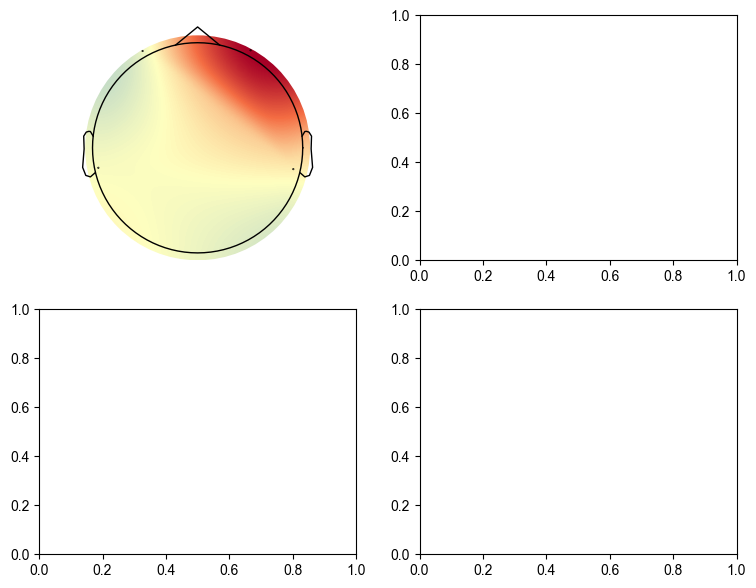

<Figure size 640x480 with 0 Axes>

In [12]:
# Banda a analizar
band = "TEI"

# --- p1 ---
p1_shared_topo = get_topo_values(p1_shared_z, band=band, session_col="Session")
p1_indiv_topo  = get_topo_values(p1_indiv_z,  band=band, session_col="Session")

# --- p2 ---
p2_shared_topo = get_topo_values(p2_shared_z, band=band, session_col="Session")
p2_indiv_topo  = get_topo_values(p2_indiv_z,  band=band, session_col="Session")

# Escala común para comparabilidad visual
all_vals = np.concatenate([
    p1_shared_topo.values, p1_indiv_topo.values,
    p2_shared_topo.values, p2_indiv_topo.values
])
vmin, vmax = all_vals.min(), all_vals.max()

fig = plot_topomap_grid(p1_shared_topo, p1_indiv_topo,
                  p2_shared_topo, p2_indiv_topo,
                  band=band)
fig.savefig(rf'Figures\Topoplot_{band.lower()}.png',dpi=300)



c:\Users\josee\OneDrive\Documentos\GitHub\NeuroHAD2025\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\josee\OneDrive\Documentos\GitHub\NeuroHAD2025\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


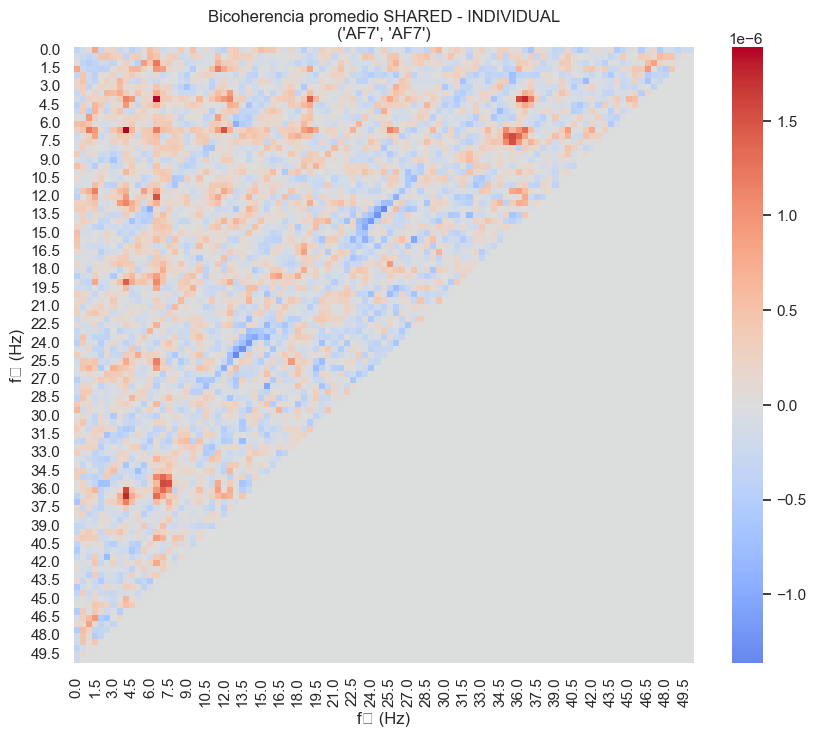

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sessions = [2, 12, 14, 21, 27, 28, 31, 39, 41, 42]
channels = ["TP9", "TP10", "AF7", "AF8"]
ch_pair = ("AF7", "AF7")  # el par que quieres analizar


# Tomamos una sesión de referencia para índices (asumo mismas freqs en todas)
ref_sn = sessions[0]
freqs = bico_data["shared"][ref_sn][ch_pair].index

# Stack de matrices: shape (n_sessions, F, F)
shared_stack = np.stack(
    [bico_data["shared"][sn][ch_pair].to_numpy() for sn in sessions],
    axis=0
)
ind_stack = np.stack(
    [bico_data["individual"][sn][ch_pair].to_numpy() for sn in sessions],
    axis=0
)

# Promedio sobre sesiones
mean_shared = shared_stack.mean(axis=0)
mean_ind    = ind_stack.mean(axis=0)

# Diferencia promedio SHARED - INDIVIDUAL
diff_mean = mean_shared - mean_ind

# Lo volvemos DataFrame para facilitar el heatmap
diff_df = pd.DataFrame(diff_mean, index=freqs, columns=freqs)

plt.figure(figsize=(10, 8))
sns.heatmap(diff_df, cmap="coolwarm", center=0)
plt.title(f"Bicoherencia promedio SHARED - INDIVIDUAL\n{ch_pair}")
plt.xlabel("f₂ (Hz)")
plt.ylabel("f₁ (Hz)")
plt.show()


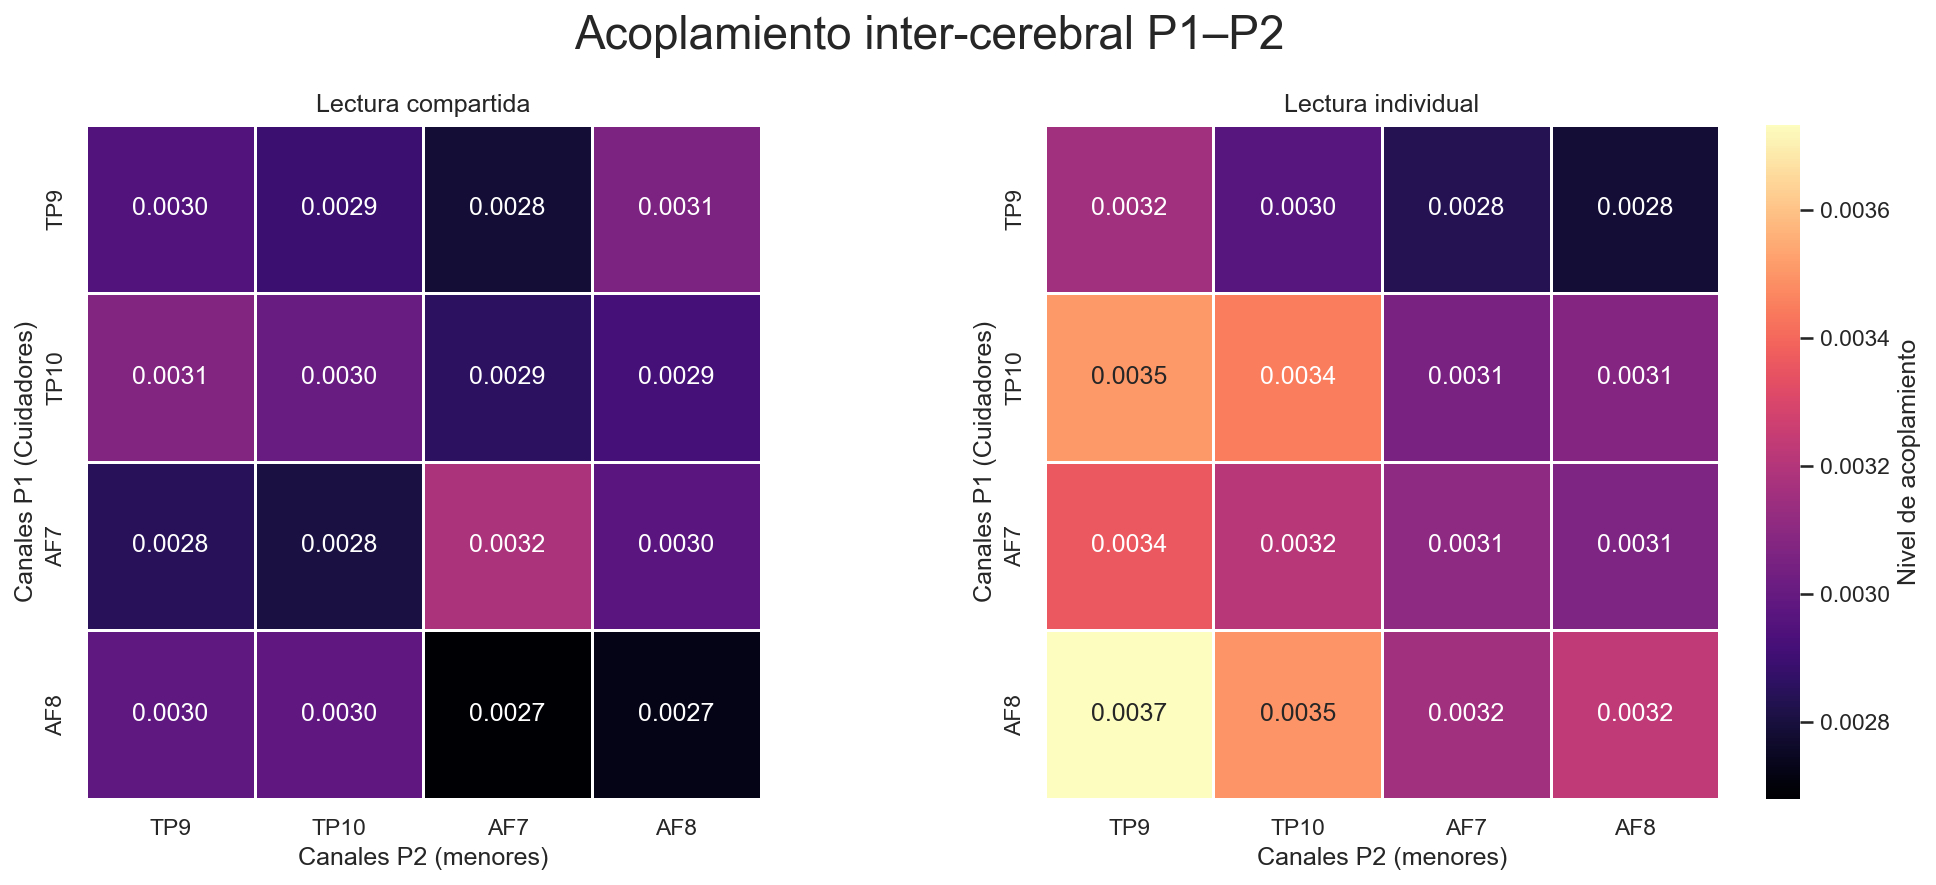

In [18]:
import numpy as np

def sync_index(df):
    return df.to_numpy().sum()

def coupling_graph(stage):
    """Matriz de acoplamiento promedio entre sesiones para un stage."""
    graph = np.zeros((len(channels), len(channels)))
    for i, ch1 in enumerate(channels):
        for j, ch2 in enumerate(channels):
            vals = [
                sync_index(bico_data[stage][sn][(ch1, ch2)])
                for sn in sessions
            ]
            graph[i, j] = np.mean(vals)
    return graph


sns.set_theme(style="white")

# Calculamos los grafos
graph_shared = coupling_graph("shared")
graph_ind    = coupling_graph("individual")

# Misma escala para los dos
vmin = min(graph_shared.min(), graph_ind.min())
vmax = max(graph_shared.max(), graph_ind.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

# --- SHARED ---
sns.heatmap(
    graph_shared,
    ax=axes[0],
    annot=True, fmt=".4f",
    cmap="magma",          # cámbialo si quieres otra paleta
    vmin=vmin, vmax=vmax,  # misma escala
    linewidths=0.5, linecolor="white",
    square=True,
    cbar=False,            # solo colorbar en el de la derecha
    xticklabels=channels,
    yticklabels=channels,
)
axes[0].set_title("Lectura compartida")
axes[0].set_xlabel("Canales P2 (menores)")
axes[0].set_ylabel("Canales P1 (Cuidadores)")

# --- INDIVIDUAL ---
hm = sns.heatmap(
    graph_ind,
    ax=axes[1],
    annot=True, fmt=".4f",
    cmap="magma",
    vmin=vmin, vmax=vmax,  # misma escala
    linewidths=0.5, linecolor="white",
    square=True,
    xticklabels=channels,
    yticklabels=channels,
    cbar_kws={"label": "Nivel de acoplamiento"},
)
axes[1].set_title("Lectura individual")
axes[1].set_xlabel("Canales P2 (menores)")
axes[1].set_ylabel("Canales P1 (Cuidadores)")

fig.suptitle("Acoplamiento inter-cerebral P1–P2", fontsize=20, y=1.03)
plt.suptitle("Acoplamiento inter-cerebral P1–P2", y=0.98, fontsize=22)

plt.tight_layout()

plt.savefig(r'C:\Users\josee\OneDrive\Documentos\GitHub\NeuroHAD2025\FILAnalysis\Figures\coupling.png',dpi=300)
plt.show()


In [22]:
import pandas as pd
import numpy as np

# Construimos el dataframe para graficar
rows = []

rows.append({
    "Participante": "P1 (Cuidadores)",
    "Condición": "Lectura compartida",
    "valor": p1_shared_z["AlphaAsymmetry"].mean(),
    "sem":   p1_shared_z["AlphaAsymmetry"].std(ddof=1) / np.sqrt(len(p1_shared_z))
})

rows.append({
    "Participante": "P1 (Cuidadores)",
    "Condición": "Lectura individual",
    "valor": p1_indiv_z["AlphaAsymmetry"].mean(),
    "sem":   p1_indiv_z["AlphaAsymmetry"].std(ddof=1) / np.sqrt(len(p1_indiv_z))
})

rows.append({
    "Participante": "P2 (Menores)",
    "Condición": "Lectura compartida",
    "valor": p2_shared_z["AlphaAsymmetry"].mean(),
    "sem":   p2_shared_z["AlphaAsymmetry"].std(ddof=1) / np.sqrt(len(p2_shared_z))
})

rows.append({
    "Participante": "P2 (Menores)",
    "Condición": "Lectura individual",
    "valor": p2_indiv_z["AlphaAsymmetry"].mean(),
    "sem":   p2_indiv_z["AlphaAsymmetry"].std(ddof=1) / np.sqrt(len(p2_indiv_z))
})

df_alpha = pd.DataFrame(rows)
df_alpha



,Participante,Condición,valor,sem
0,P1 (Cuidadores),Lectura compartida,0.428662,0.033681
1,P1 (Cuidadores),Lectura individual,0.977680,0.044477
2,P2 (Menores),Lectura compartida,0.376308,0.036665
3,P2 (Menores),Lectura individual,0.040522,0.040227


C:\Users\josee\AppData\Local\Temp\ipykernel_25676\552603301.py:19: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'black'}` instead.

  ax = sns.barplot(
C:\Users\josee\AppData\Local\Temp\ipykernel_25676\552603301.py:19: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.4}` instead.

  ax = sns.barplot(


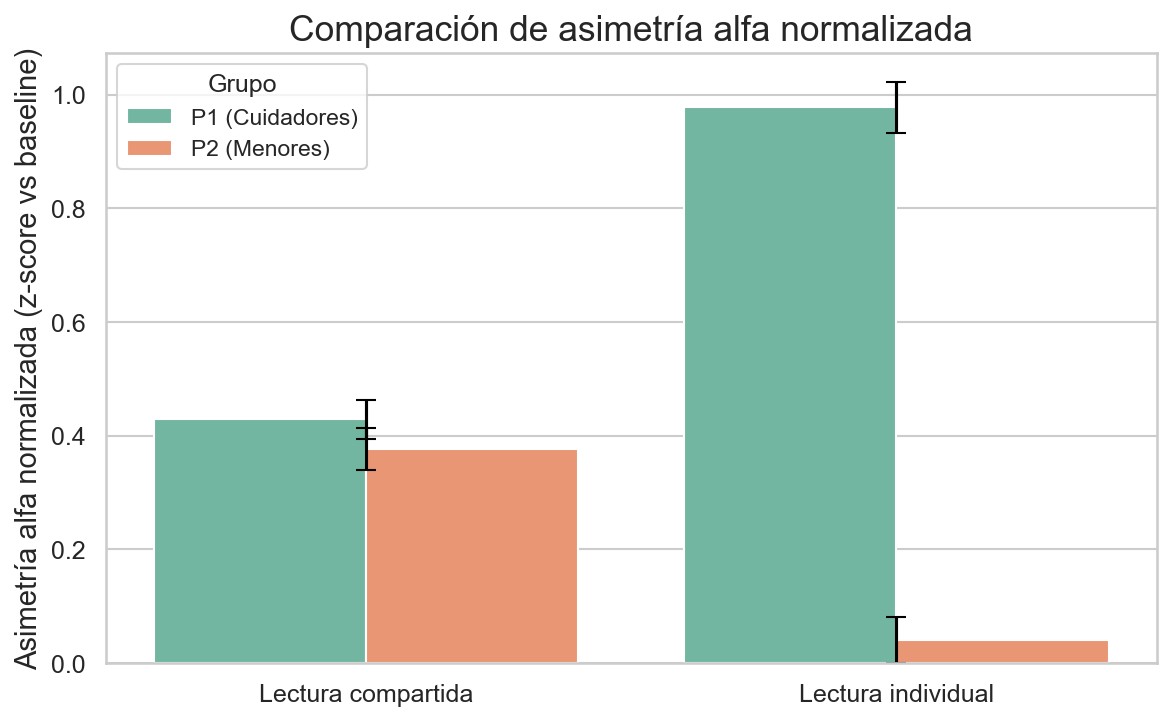

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 17,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

# Orden de categorías para que salga bien estructurado
order_cond = ["Lectura compartida", "Lectura individual"]
order_part = ["P1 (Cuidadores)", "P2 (Menores)"]

plt.figure(figsize=(8,5), dpi=150)

ax = sns.barplot(
    data=df_alpha,
    x="Condición",
    y="valor",
    hue="Participante",
    hue_order=order_part,
    order=order_cond,
    palette="Set2",
    capsize=0.12,
    errcolor="black",
    errwidth=1.4
)

# Ajustamos barras de error manualmente (SEM)
for i, row in df_alpha.iterrows():
    ax.errorbar(
        x=[row["Condición"]],
        y=[row["valor"]],
        yerr=[row["sem"]],
        fmt="none",
        color="black",
        capsize=5
    )

ax.set_ylabel("Asimetría alfa normalizada (z-score vs baseline)")
ax.set_xlabel("")
ax.set_title("Comparación de asimetría alfa normalizada")

ax.legend(title="Grupo")

plt.tight_layout()
plt.show()
